In [1]:
import typing as t

import polars as pl

from src.config.constants import Product
from src.research import (
    AnalysisResult,
    OrderbookAnalysisResult,
    Plots,
    TradesAnalysisResult,
    display_plots,
    run_analysis,
)

ASH_COATED_OSMIUM: t.Final[Product] = Product.ASH_COATED_OSMIUM
ROUND: t.Final[int] = 1
DAY: t.Final[int] = -2

analysis_result: t.Final[AnalysisResult] = run_analysis(ROUND, DAY, ASH_COATED_OSMIUM)
orderbook_analysis: t.Final[OrderbookAnalysisResult] = (
    analysis_result.orderbook_analysis_result
)
trades_analysis: t.Final[TradesAnalysisResult] = analysis_result.trades_analysis_result
plots: t.Final[Plots] = analysis_result.plots

# Orderbook Analysis

In [2]:
orderbook_data: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_data
orderbook_features_data: t.Final[pl.DataFrame] = (
    orderbook_analysis.orderbook_features_data
)
orderbook_stats: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_stats
orderbook_corrs: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_corrs

orderbook_data

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,midprice_dev,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,i64
0,null,null,null,null,null,null,10010,25,null,null,null,null,10010.0,null,-1.0,11.830094,null,-0.001,null,null,null
100,9992,15,null,null,null,null,10008,15,10011,20,null,null,10000.0,16,-0.4,1.830094,-0.001,0.0,10000.0,0.0,30
200,9992,15,9989,30,null,null,10008,15,10010,30,null,null,10000.0,16,0.0,1.830094,0.0,0.0,10000.0,0.0,30
300,9992,13,9989,26,null,null,10008,13,10010,26,null,null,10000.0,16,0.0,1.830094,0.0,0.0,10000.0,0.0,26
400,9992,15,null,null,null,null,10008,15,10010,20,null,null,10000.0,16,-0.4,1.830094,0.0,0.0,10000.0,0.0,30
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,9984,13,9982,24,null,null,10000,13,10003,24,null,null,9992.0,16,0.0,-6.169906,0.0,0.0,9992.0,0.0,26
999600,9984,15,9982,30,null,null,10000,15,10003,30,null,null,9992.0,16,0.0,-6.169906,0.0,0.0,9992.0,0.0,30
999700,9984,10,9982,22,null,null,10000,10,10003,22,null,null,9992.0,16,0.0,-6.169906,0.0,-0.000801,9992.0,0.0,20


In [3]:
orderbook_features_data

timestamp,mid_price,midprice_dev,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,f64,f64,i64,f64,f64,f64,f64,f64,i64
0,10010.0,11.830094,null,-1.0,null,-0.001,null,null,null
100,10000.0,1.830094,16,-0.4,-0.001,0.0,10000.0,0.0,30
200,10000.0,1.830094,16,0.0,0.0,0.0,10000.0,0.0,30
300,10000.0,1.830094,16,0.0,0.0,0.0,10000.0,0.0,26
400,10000.0,1.830094,16,-0.4,0.0,0.0,10000.0,0.0,30
…,…,…,…,…,…,…,…,…,…
999500,9992.0,-6.169906,16,0.0,0.0,0.0,9992.0,0.0,26
999600,9992.0,-6.169906,16,0.0,0.0,0.0,9992.0,0.0,30
999700,9992.0,-6.169906,16,0.0,0.0,-0.000801,9992.0,0.0,20


In [4]:
orderbook_stats

statistic,mid_price,midprice_dev,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",9982.0,9982.0,9187.0,9982.0,9981.0,9981.0,9187.0,9187.0,9187.0
"""null_count""",0.0,0.0,795.0,0.0,1.0,1.0,795.0,795.0,795.0
"""mean""",9998.169906,6.4144e-14,16.149777,0.001025,-1.6529e-7,-1.6529e-7,9998.118413,-0.043337,28.223686
"""std""",5.219914,5.219914,2.538189,0.386343,0.000377,0.000377,4.699541,1.778956,7.766033
"""min""",9979.0,-19.169906,5.0,-1.0,-0.002099,-0.002099,9985.095238,-5.6875,12.0
"""25%""",9994.5,-3.669906,16.0,-0.169231,-0.0001,-0.0001,9995.0,0.0,22.0
"""50%""",9998.0,-0.169906,16.0,0.0,0.0,0.0,9998.0,0.0,28.0
"""75%""",10002.0,3.830094,18.0,0.178082,0.0001,0.0001,10001.7,0.0,32.0
"""max""",10019.0,20.830094,21.0,1.0,0.0021,0.0021,10011.6,5.25,60.0


In [5]:
orderbook_corrs

imb_corr,micro_corr
f64,f64
0.418992,0.314701


# Trades Analysis

In [6]:
trades_data: t.Final[pl.DataFrame] = trades_analysis.trades_data
time_interval_stats: t.Final[pl.DataFrame] = trades_analysis.time_interval_stats
quantities_stats: t.Final[pl.DataFrame] = trades_analysis.quantities_stats
order_side_stats: t.Final[pl.DataFrame] = trades_analysis.order_side_stats
trade_price_streaks_stats: t.Final[pl.DataFrame] = (
    trades_analysis.trade_price_streaks_stats
)

trades_data

timestamp,price,quantity,best_bid,best_ask,mid_price,time_since_prev_trade,time_until_next_trade,mid_price_dev,side_heur
i64,f64,i64,i64,i64,f64,i64,i64,f64,str
700,9990.0,6,9990,10011,10000.5,null,200,-10.5,"""SELL_ORDER"""
900,9998.0,2,9993,9998,9995.5,200,1600,2.5,"""BUY_ORDER"""
2500,10011.0,8,9992,10011,10001.5,1600,3600,9.5,"""BUY_ORDER"""
6100,10013.0,8,9997,10013,10005.0,3600,6800,8.0,"""BUY_ORDER"""
12900,10001.0,9,10001,null,10001.0,6800,900,0.0,"""UNKNOWN"""
…,…,…,…,…,…,…,…,…,…
980800,10000.0,3,9981,10000,9990.5,3700,7200,9.5,"""BUY_ORDER"""
988000,9981.0,4,9981,9999,9990.0,7200,4000,-9.0,"""SELL_ORDER"""
992000,9983.0,4,9983,9999,9991.0,4000,2200,-8.0,"""SELL_ORDER"""


In [7]:
time_interval_stats

time_since_prev_mean,time_since_prev_var,time_since_prev_std,time_until_next_mean,time_until_next_var,time_until_next_std
f64,f64,f64,f64,f64,f64
2323.831776,5.7391e6,2395.642471,2323.831776,5.7391e6,2395.642471


In [8]:
quantities_stats

qty_mean,qty_median,qty_mode,qty_var,qty_std
f64,f64,i64,f64,f64
5.151515,5.0,6,5.184933,2.277045


In [9]:
order_side_stats

total_orders,buy_orders,buy_order_rate,sell_orders,sell_order_rate
i64,i64,f64,i64,f64
429,206,0.480186,210,0.48951


In [10]:
trade_price_streaks_stats

price,streak_length
f64,u32
9986.0,1
9990.0,1
9990.0,1
10005.0,2
9983.0,1
…,…
9994.0,1
9993.0,3
9994.0,1


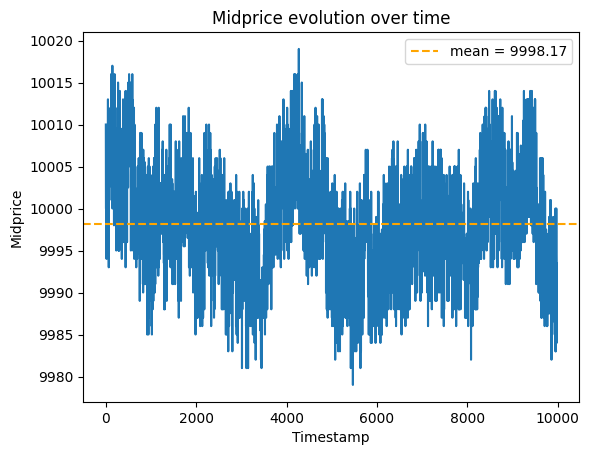

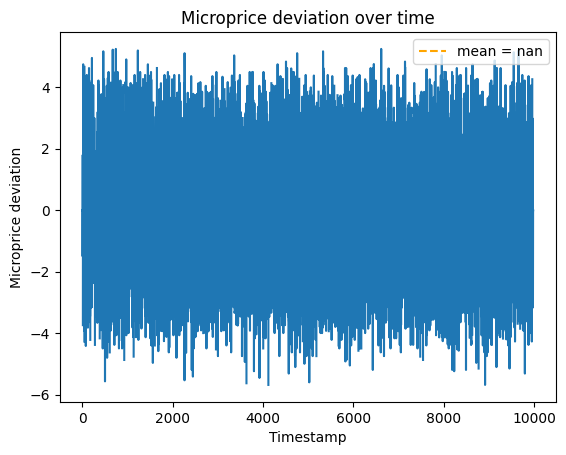

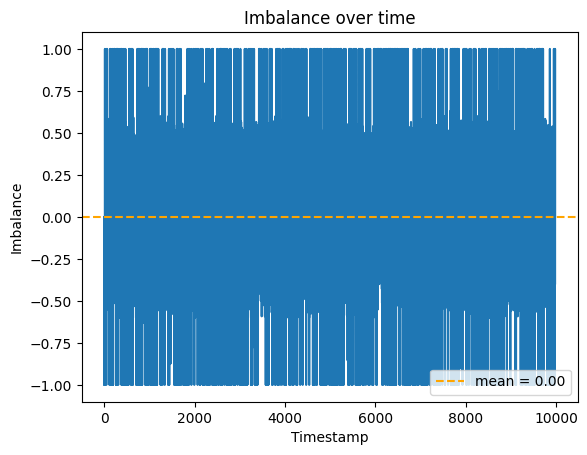

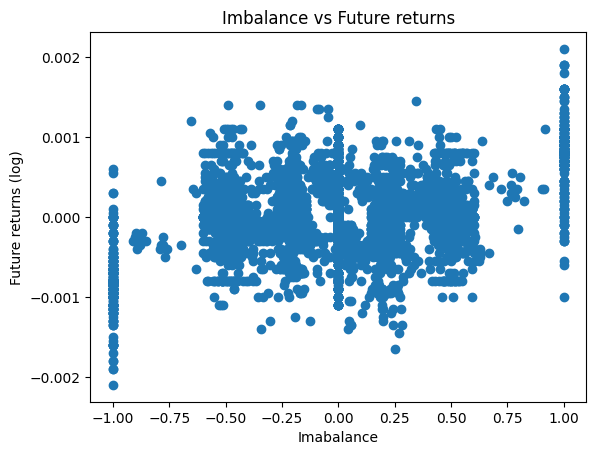

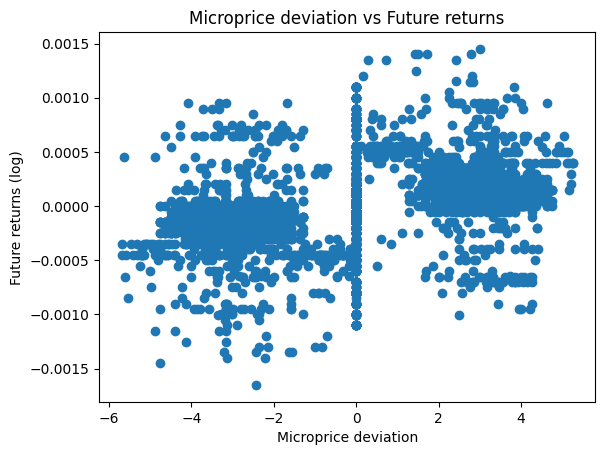

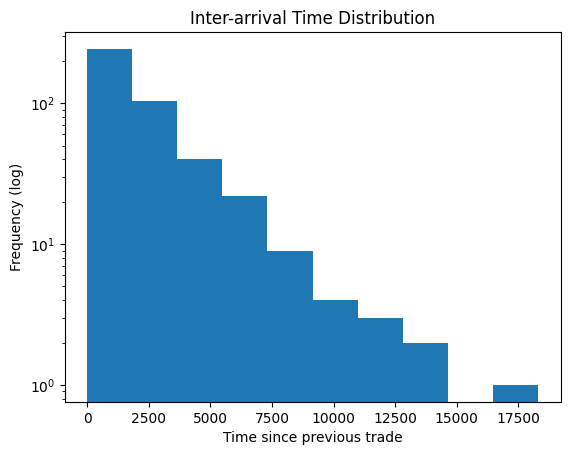

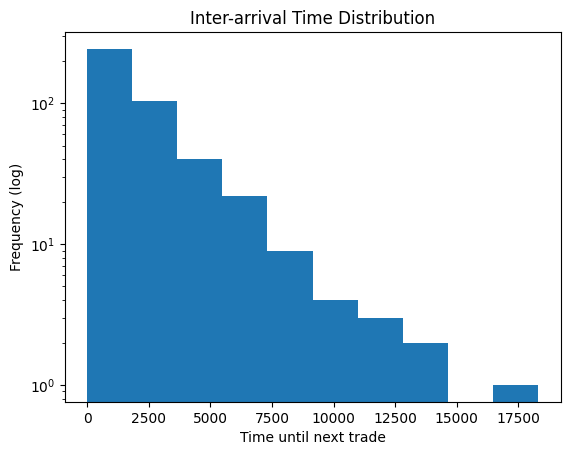

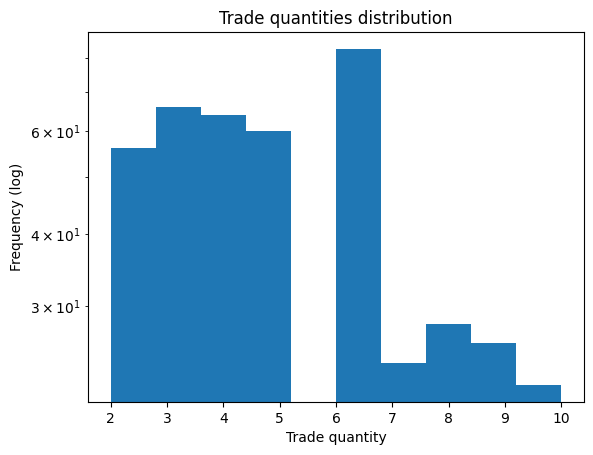

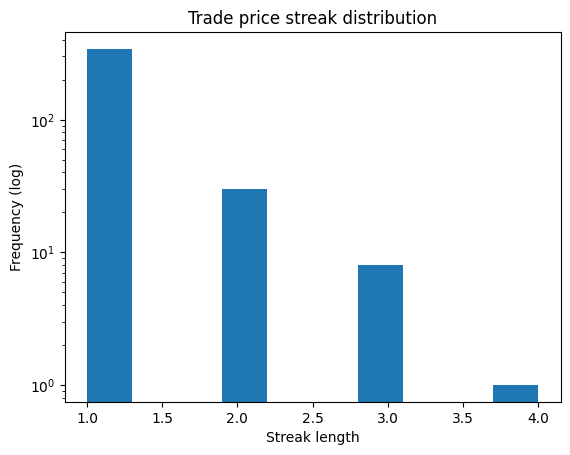

In [11]:
display_plots(plots)